### B Vidakovic Quantum Framework for Wavelet Shrinkage
## Example 11

## Quantum Unitary Soft Thresholding (No Ancilla)

This notebook implements a **fully unitary, measurement-free shrinkage operator** acting on amplitude-encoded wavelet coefficients.  
The method emulates *soft thresholding* while preserving coherence, making it a prototype for **quantum denoising without ancillas or noise channels**.

---

### 1. Concept

Given a vector of noisy wavelet coefficients $d = (d_0, \dots, d_{N-1})$,  
we wish to attenuate small coefficients while retaining the large ones,  
analogous to the classical soft thresholding rule

$$
\tilde{d}_i = \operatorname{sign}(d_i) \max(|d_i| - \tau, 0).
$$

Instead of applying a non-unitary truncation,  
we construct a **unitary reparametrization** of amplitudes:

$$
|d_i'| = |d_i|^{\gamma}, \quad \gamma > 1.
$$

This mapping compresses small amplitudes and preserves phase (sign) information.  
It can be realized through a single-qubit $R_y(\theta)$ rotation satisfying

$$
\sin^2(\tfrac{\theta_i}{2}) = |d_i|^{\gamma}.
$$

Each coefficient is thus represented by a qubit whose probability of measuring $|1\rangle$ equals $|d_i|^{\gamma}$.

---

### 2. Algorithm Steps

1. **Normalize** raw coefficients to the interval $[-1, 1]$ for amplitude encoding.  
2. **Choose** an exponent parameter $\gamma$ controlling shrinkage strength.  
   - $\gamma = 1$: no shrinkage (identity)  
   - $\gamma > 1$: stronger attenuation of small magnitudes  
3. **For each coefficient** $d_i$:
   - Compute $p = |d_i|$ and $p' = p^{\gamma}$  
   - Solve $\theta_i = 2 \arcsin(\sqrt{p'})$  
   - Apply an $R_y(\theta_i)$ rotation to initialize the qubit  
   - Extract the new probability $P(|1\rangle) = |d_i'|$  
4. **Preserve sign** of the original amplitude as a phase factor.

---

### 3. Comparison with Other Quantum Shrinkage Models

| Method | Mechanism | Coherence | Extra Qubits | Interpretation |
|--------|------------|------------|---------------|----------------|
| **Ancilla-based** | Controlled rotations with ancillary qubits | Pure until ancilla traced | Yes | Programmable but non-minimal |
| **Phase damping** | Kraus map attenuating off-diagonals | Mixed state | No | Emulates decoherence |
| **Amplitude damping** | Kraus map on populations | Mixed state | No | Models energy relaxation |
| **Unitary soft (this)** | $R_y$-based reparametrization | **Fully coherent** | **No** | Deterministic and reversible |

---

### 4. Output Interpretation

The plot produced by the script shows:
- Blue markers: normalized input amplitudes (scaled wavelet coefficients)  
- Red markers: shrunk amplitudes after unitary transformation  
- Vertical dotted lines: contraction amount for each coefficient  

The transformation is smooth, monotonic, and completely unitary —  
suitable as a **quantum layer** in more complex denoising or inference circuits.

---

### 5. Remarks

- The parameter $\gamma$ can depend on scale or coefficient index,  
  allowing **level-dependent quantum thresholding**.  
- For $\gamma \to \infty$, small amplitudes collapse toward 0,  
  approaching a hard-threshold-like limit.  
- Because the operation is unitary, it can be integrated into  
  variational or hybrid quantum algorithms and reversed if necessary.

---


Normalized input: [ 0.263  0.158  1.     0.053  0.368 -1.     0.263  0.474]

Original: [ 0.2632  0.1579  1.      0.0526  0.3684 -1.      0.2632  0.4737]
Shrunk  : [ 0.0904  0.0361  1.      0.005   0.1657 -1.      0.0904  0.2605]


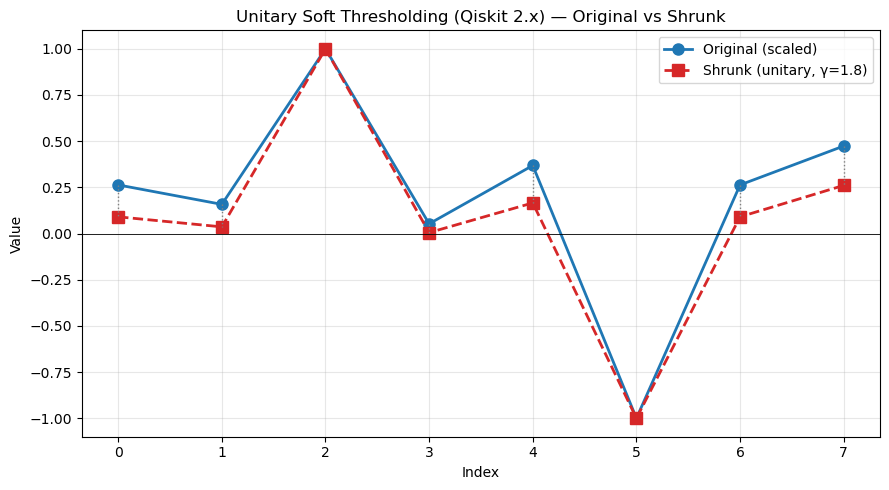

In [1]:
# ============================================================
#  Quantum Unitary Soft Thresholding (no ancilla)
#  Compatible with Qiskit 2.x
#  Author: Brani Vidakovic (2025)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ----- 1. Input data -----
dd = np.array([2, 1, 9, 0, 3, -10, 2, 4], dtype=float)

# Normalize to [-1, 1] for amplitude encoding
d = 2 * (dd - dd.min()) / (dd.max() - dd.min()) - 1
print("Normalized input:", np.round(d, 3))

# ----- 2. Parameters -----
gamma = 1.8  # exponent controlling softness (γ > 1 = stronger shrinkage)

# ----- 3. Unitary soft-threshold function -----
def unitary_soft_threshold(value, gamma=1.8):
    """
    Simulates a unitary shrinkage operation where
    the amplitude magnitude |d| is reparametrized as |d'| = |d|^γ.
    Implemented as a Ry rotation producing P(|1>) = |d|^γ.
    """
    sign = np.sign(value)
    p = abs(value)
    p_target = p ** gamma

    # Build single-qubit circuit: sin²(θ/2) = p_target → θ = 2 * arcsin(√p_target)
    theta = 2 * np.arcsin(np.sqrt(p_target))
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)

    # Get final probability of |1>
    state = Statevector.from_instruction(qc)
    prob_1 = np.abs(state.data[1])**2

    return sign * prob_1


# ----- 4. Apply shrinkage -----
shrunk = np.array([unitary_soft_threshold(v, gamma) for v in d])

# ----- 5. Print results -----
print("\nOriginal:", np.round(d, 4))
print("Shrunk  :", np.round(shrunk, 4))

# ----- 6. Plot overlay -----
x = np.arange(len(d))

plt.figure(figsize=(9,5))
plt.plot(x, d, 'o-', lw=2, label='Original (scaled)', color='tab:blue', markersize=8)
plt.plot(x, shrunk, 's--', lw=2, label=f'Shrunk (unitary, γ={gamma})', color='tab:red', markersize=8)

# Connect with lines
for xi, y0, y1 in zip(x, d, shrunk):
    plt.plot([xi, xi], [y0, y1], color='gray', linestyle=':', linewidth=1)

plt.axhline(0, color='black', lw=0.6)
plt.xticks(x)
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Unitary Soft Thresholding (Qiskit 2.x) — Original vs Shrunk')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save image files
plt.savefig("ex11unitary_soft.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("ex11unitary_soft.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


## Mixed (Hybrid) Models for Quantum Shrinkage

Between the two extremes — **unitary reparametrization** and **fully decohering channels** — 
lies a powerful class of *mixed models* that combine reversible and irreversible processes.  
These models are well suited for **quantum wavelet denoising**, where we want controlled amplitude suppression 
without destroying superposition structure.

---

### 1. Partial-Trace (Ancilla–Noise Hybrid) Model

Here, an **ancilla qubit** mediates a smooth transition between unitary shrinkage and dissipative damping.  
We apply a controlled rotation as in ancilla-based schemes, but **trace out only partially** (or weakly couple) the ancilla.

Let the system–ancilla unitary be

$$
U_{\text{hyb}} = \sum_i |i\rangle\langle i| \otimes R_y(f(|c_i|)),
$$

and the reduced system state be

$$
\rho_{\text{out}} = \operatorname{Tr}_a[(I \otimes M) U_{\text{hyb}} (\rho \otimes |0\rangle\langle 0|) U_{\text{hyb}}^\dagger],
$$

where $M$ is a tunable measurement operator on the ancilla (e.g., projective, weak, or depolarizing).

- If $M = I$, no tracing → **fully unitary**.  
- If $M = |0\rangle\langle 0|$, full trace → **phase damping**–like.  
- Intermediate strengths yield **partial shrinkage**, blending both effects.

This produces a *continuous bridge* between unitary and noisy regimes.

---

### 2. Amplitude–Phase Composite Channel

Define a composite channel that simultaneously damps amplitude and phase:

$$
\mathcal{E}_{\alpha,\beta}(\rho) = 
(1-\alpha-\beta)\rho + \alpha Z\rho Z + \beta X\rho X,
$$

where $\alpha$ controls phase damping and $\beta$ controls amplitude leakage.  

- Setting $\beta = 0$ yields **pure phase damping**.  
- Setting $\alpha = 0$ gives **amplitude damping**.  
- Nonzero $(\alpha,\beta)$ produces mixed decoherence with a tunable balance.

This can emulate realistic quantum hardware noise or be used intentionally as a *shrinkage operator* in density space.

---

### 3. Hybrid Variational–Channel Model

In this formulation, a **trainable unitary layer** precedes or follows a noise channel, forming a controlled hybrid:

$$
\rho_{\text{out}} = \mathcal{E}_\theta( U(\phi) \rho U(\phi)^\dagger ),
$$

where:
- $U(\phi)$ is a parametrized unitary learned from data (e.g., a variational encoder).  
- $\mathcal{E}_\theta$ is a Kraus map with tunable damping rate $\theta$.

Training $\{\phi, \theta\}$ jointly allows the model to **adapt shrinkage shape and strength** for a specific noise level or signal class.  
This corresponds to *data-driven SPoM-type shrinkage* in quantum form.

---

### 4. Controlled Hamiltonian Decoherence

A semi-coherent mechanism achieved by evolving under a controlled Hamiltonian with weak coupling to an environment:

$$
\rho(t) = e^{-iH t} \rho(0) e^{iH t} + (1 - e^{-\Gamma t}) D[\rho(0)],
$$

where $D[\rho]$ introduces a dissipative component such as dephasing or relaxation.  
By tuning $\Gamma$, one interpolates between fully unitary evolution ($\Gamma = 0$) and full decoherence ($\Gamma \to \infty$).  
This acts as **continuous-time shrinkage** driven by the Hamiltonian $H$.

---

### 5. Classical–Quantum Feedback Shrinkage

This model preserves coherence by keeping the wavelet register untouched,  
but uses **classical feedback** from auxiliary quantum sensors to modulate shrinkage strength.  

1. A separate probe system estimates global noise variance $\sigma$.  
2. The estimated $\sigma$ is processed classically to set a threshold $\tau(\sigma)$.  
3. The threshold $\tau$ controls a parameterized gate or damping rate acting on the main register.

This realizes **adaptive quantum shrinkage** analogous to SureShrink or BayesShrink, 
but without direct measurement of wavelet coefficients.

---

### 6. Summary Table

| Model | Mechanism | Nature | Coherence | Parameters |
|--------|------------|---------|------------|-------------|
| Partial-Trace Hybrid | Ancilla + weak trace | Mixed | Partially coherent | coupling strength |
| Amplitude–Phase Channel | Composite Kraus | Mixed | Mixed | $(\alpha, \beta)$ |
| Variational–Channel | Trainable unitary + noise | Hybrid | Partially coherent | $(\phi, \theta)$ |
| Hamiltonian Decoherence | Unitary + dissipator | Continuous | Semi-coherent | $\Gamma t$ |
| Classical–Quantum Feedback | Adaptive control | Coherent main register | High | $\tau(\sigma)$ |

---

### 7. Interpretation

These mixed models allow smooth control over the **degree of shrinkage and coherence loss**.  
They are particularly valuable for quantum denoising pipelines where:
- Coherence must be largely preserved (for further processing),  
- But small noisy coefficients need attenuation,  
- And physical noise models or data-driven adaptation are essential.

Such frameworks make it possible to **engineer “quantum priors”** directly in circuit space, 
linking Bayesian shrinkage theory with physical damping and variational control.

---
